# Reto: Comparación de los 2 conjuntos de datos

Se comparan las etiquetas **originales** de MASATI-v2 (dibujadas a mano por personas) contra las etiquetas **ajustadas por SAM** (`ships_SAM/`, generadas en el reto anterior usando la caja original como *prompt*).


In [1]:
from pathlib import Path
import random
import xml.etree.ElementTree as ET

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


BASE = Path("MASATI-v2")
if not BASE.exists():
    BASE = Path.home() / "Downloads" / "MASATI-v2"
SAM_DIR = Path("ships_SAM")
if not SAM_DIR.exists():
    SAM_DIR = BASE / "ships_SAM"

COLOR_ORIG = (0, 200, 0)   # RGB: verde  -> etiqueta original
COLOR_SAM = (255, 0, 0)    # RGB: rojo   -> etiqueta SAM

SEED = 42
random.seed(SEED)

CATEGORY_NAMES = {"ship": "Un solo barco", "coast_ship": "Barco con costa", "multi": "Múltiples barcos"}

## Funciones auxiliares

In [2]:
def read_xml(xml_path):
    """Devuelve (carpeta, nombre de archivo, lista de cajas (xmin, ymin, xmax, ymax))."""
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall("object"):
        bb = obj.find("bndbox")
        boxes.append(tuple(int(bb.find(k).text) for k in ("xmin", "ymin", "xmax", "ymax")))
    return root.find("folder").text, root.find("filename").text, boxes


def box_area(b):
    return max(0, b[2] - b[0]) * max(0, b[3] - b[1])


def iou(a, b):
    """IoU entre dos cajas (xmin, ymin, xmax, ymax)."""
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = box_area(a) + box_area(b) - inter
    return inter / union if union > 0 else 0.0


# Comprobaciones rápidas de la métrica
assert iou((0, 0, 10, 10), (0, 0, 10, 10)) == 1.0
assert iou((0, 0, 10, 10), (20, 20, 30, 30)) == 0.0
assert abs(iou((0, 0, 10, 10), (5, 0, 15, 10)) - 1 / 3) < 1e-9

## Carga y emparejamiento de las etiquetas originales y las de SAM

In [3]:
pairs = []  # un elemento por imagen
for sam_xml in sorted(SAM_DIR.glob("*.xml")):
    folder, filename, boxes_sam = read_xml(sam_xml)
    orig_xml = BASE / f"{folder}_labels" / sam_xml.name
    _, _, boxes_orig = read_xml(orig_xml)
    if len(boxes_orig) != len(boxes_sam):
        print(f"[AVISO] {sam_xml.name}: {len(boxes_orig)} cajas originales vs {len(boxes_sam)} SAM -> se omite")
        continue
    pairs.append({"folder": folder, "file": filename, "orig": boxes_orig, "sam": boxes_sam,
                  "image": BASE / folder / filename})

df_pairs = pd.DataFrame(pairs)
print(f"Imágenes emparejadas: {len(df_pairs)}  |  cajas totales: {sum(len(p['orig']) for p in pairs)}")
df_pairs.assign(n_cajas=df_pairs["orig"].map(len)).groupby("folder").agg(imagenes=("file", "count"), cajas=("n_cajas", "sum"))

Imágenes emparejadas: 21  |  cajas totales: 47


,imagenes,cajas
folder,,
coast_ship,7,7
multi,7,33
ship,7,7


## Etiqueta original (verde) vs. etiqueta SAM (rojo)

Se eligen 2 imágenes aleatorias de cada tipo. El número junto a cada caja es su IoU.

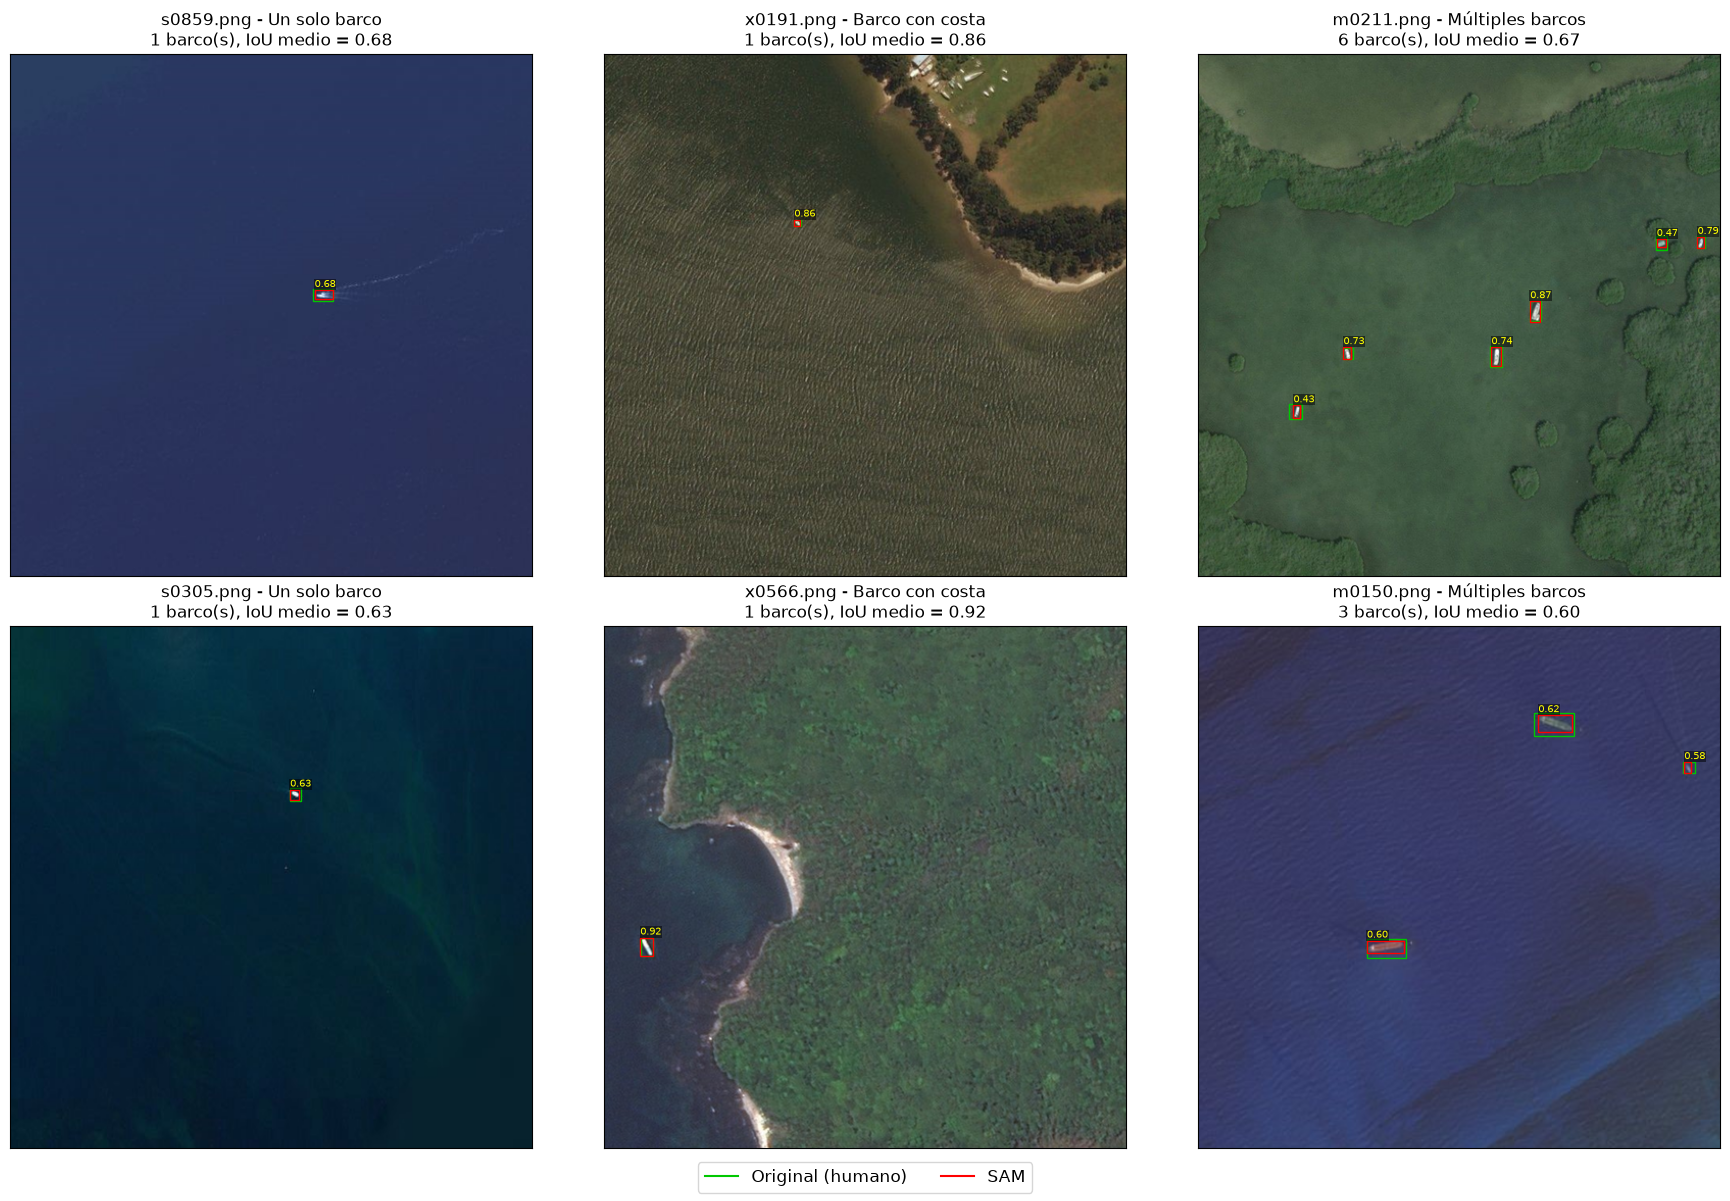

In [4]:
def load_rgb(path):
    return cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)


def draw_comparison(ax, pair, show_iou=True, lw=1.0):
    img = load_rgb(pair["image"])
    ax.imshow(img)
    for bo, bs in zip(pair["orig"], pair["sam"]):
        for b, c in ((bo, COLOR_ORIG), (bs, COLOR_SAM)):
            ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, edgecolor=np.array(c) / 255, linewidth=lw))
        if show_iou:
            ax.text(bs[0], max(bs[1] - 3, 8), f"{iou(bo, bs):.2f}", color="yellow", fontsize=7,
                    bbox=dict(facecolor="black", alpha=0.5, pad=0.5, edgecolor="none"))
    ax.set_xticks([]); ax.set_yticks([])


rng = random.Random(SEED)
samples = []
for cat in ("ship", "coast_ship", "multi"):
    cands = [p for p in pairs if p["folder"] == cat]
    samples += rng.sample(cands, 2)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, p in enumerate(samples):
    ax = axes[i % 2, i // 2]
    draw_comparison(ax, p)
    ious = [iou(a, b) for a, b in zip(p["orig"], p["sam"])]
    ax.set_title(f"{p['file']} - {CATEGORY_NAMES[p['folder']]}\n{len(ious)} barco(s), IoU medio = {np.mean(ious):.2f}")
fig.legend(handles=[plt.Line2D([], [], color=np.array(COLOR_ORIG) / 255, label="Original (humano)"),
                    plt.Line2D([], [], color=np.array(COLOR_SAM) / 255, label="SAM")],
           loc="lower center", ncol=2, fontsize=12)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

### Zoom sobre los barcos

Recorte ampliado alrededor de cada barco (primer barco de cada imagen anterior) para apreciar mejor cuánto difieren las cajas.

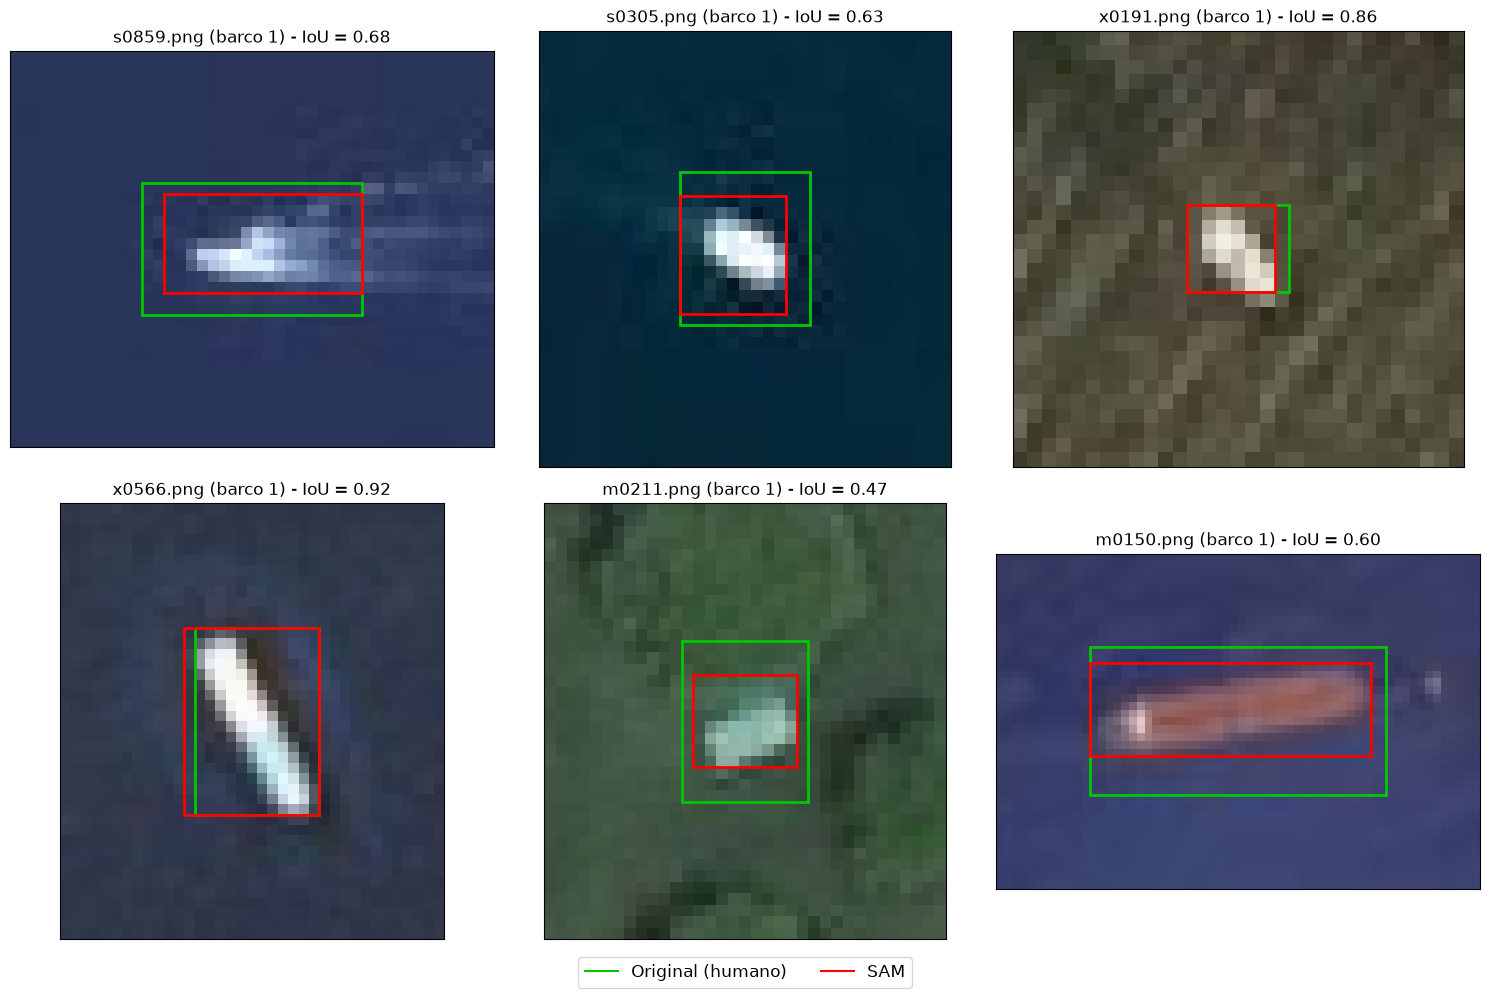

In [5]:
def zoom_crop(pair, idx=0, margin=12):
    img = load_rgb(pair["image"])
    bo, bs = pair["orig"][idx], pair["sam"][idx]
    x1 = max(0, min(bo[0], bs[0]) - margin); y1 = max(0, min(bo[1], bs[1]) - margin)
    x2 = min(img.shape[1], max(bo[2], bs[2]) + margin); y2 = min(img.shape[0], max(bo[3], bs[3]) + margin)
    return img[y1:y2, x1:x2], (bo[0] - x1, bo[1] - y1, bo[2] - x1, bo[3] - y1), (bs[0] - x1, bs[1] - y1, bs[2] - x1, bs[3] - y1)


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, p in zip(axes.ravel(), samples):
    crop, bo, bs = zoom_crop(p)
    ax.imshow(crop)
    for b, c in ((bo, COLOR_ORIG), (bs, COLOR_SAM)):
        ax.add_patch(plt.Rectangle((b[0] - 0.5, b[1] - 0.5), b[2] - b[0], b[3] - b[1], fill=False,
                                   edgecolor=np.array(c) / 255, linewidth=2))
    ax.set_title(f"{p['file']} (barco 1) - IoU = {iou(p['orig'][0], p['sam'][0]):.2f}")
    ax.set_xticks([]); ax.set_yticks([])
fig.legend(handles=[plt.Line2D([], [], color=np.array(COLOR_ORIG) / 255, label="Original (humano)"),
                    plt.Line2D([], [], color=np.array(COLOR_SAM) / 255, label="SAM")],
           loc="lower center", ncol=2, fontsize=12)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## Medición cuantitativa: IoU por caja

Tabla con una fila por barco: tamaño de cada caja, razón de áreas (SAM / original) y su IoU.

In [6]:
rows = []
for p in pairs:
    for i, (bo, bs) in enumerate(zip(p["orig"], p["sam"])):
        ao, as_ = box_area(bo), box_area(bs)
        rows.append({"categoria": p["folder"], "imagen": p["file"], "barco": i + 1,
                     "area_orig": ao, "area_sam": as_, "razon_area": as_ / ao if ao else np.nan,
                     "iou": iou(bo, bs)})
df = pd.DataFrame(rows)

# Verificación de alineación: el IoU con la caja del mismo índice no debería ser peor que el mejor emparejamiento posible
mis = 0
for p in pairs:
    for i, bo in enumerate(p["orig"]):
        if max(iou(bo, bs) for bs in p["sam"]) > iou(bo, p["sam"][i]) + 1e-9:
            mis += 1
print(f"Cajas con posible desalineación de índice: {mis}")
assert df["iou"].between(0, 1).all()
df.round(3)

Cajas con posible desalineación de índice: 0


,categoria,imagen,barco,area_orig,area_sam,razon_area,iou
0,multi,m0114.png,1,406,351,0.865,0.701
1,multi,m0114.png,2,192,154,0.802,0.802
2,multi,m0114.png,3,126,112,0.889,0.608
3,multi,m0114.png,4,112,108,0.964,0.618
4,multi,m0150.png,1,722,432,0.598,0.598
5,multi,m0150.png,2,858,528,0.615,0.615
6,multi,m0150.png,3,132,77,0.583,0.583
7,multi,m0211.png,1,154,72,0.468,0.468
8,multi,m0211.png,2,84,66,0.786,0.786
9,multi,m0211.png,3,209,200,0.957,0.868


In [7]:
resumen = df.groupby("categoria")["iou"].agg(
    barcos="count", media="mean", mediana="median", minimo="min", maximo="max", desv_std="std",
    pct_iou_menor_05=lambda s: 100 * (s < 0.5).mean(),
).round(3)
resumen.loc["TOTAL"] = [len(df), df["iou"].mean(), df["iou"].median(), df["iou"].min(), df["iou"].max(),
                        df["iou"].std(), 100 * (df["iou"] < 0.5).mean()]
resumen.round(3)

,barcos,media,mediana,minimo,maximo,desv_std,pct_iou_menor_05
categoria,,,,,,,
coast_ship,7.0,0.784,0.833,0.500,1.000,0.183,0.000
multi,33.0,0.585,0.598,0.312,0.868,0.159,33.333
ship,7.0,0.550,0.536,0.414,0.721,0.126,42.857
TOTAL,47.0,0.609,0.608,0.312,1.000,0.172,29.787


In [8]:
# Por imagen (IoU medio de sus barcos)
por_imagen = df.groupby(["categoria", "imagen"]).agg(barcos=("iou", "count"), iou_medio=("iou", "mean"),
                                                     iou_min=("iou", "min"), iou_max=("iou", "max")).round(3)
por_imagen

barcos  iou_medio  iou_min  iou_max
categoria  imagen                                        
coast_ship x0191.png       1      0.857    0.857    0.857
           x0209.png       1      0.571    0.571    0.571
           x0405.png       1      1.000    1.000    1.000
           x0412.png       1      0.500    0.500    0.500
           x0451.png       1      0.806    0.806    0.806
           x0566.png       1      0.923    0.923    0.923
           x0711.png       1      0.833    0.833    0.833
multi      m0114.png       4      0.682    0.608    0.802
           m0150.png       3      0.599    0.583    0.615
           m0211.png       6      0.669    0.429    0.868
           m0222.png       2      0.625    0.536    0.714
           m0224.png       6      0.452    0.359    0.556
           m0230.png       9      0.508    0.312    0.826
           y0031.png       3      0.740    0.667    0.788
ship       s0305.png       1      0.629    0.629    0.629
           s0571.png       1      0.426    0.426    0.426
           s0594.png       1      0.721    0.721    0.721
           s0812.png       1      0.536    0.536    0.536
           s0834.png       1      0.448    0.448    0.448
           s0859.png       1      0.675    0.675    0.675
           s0913.png       1      0.414    0.414    0.414

Correlación (Pearson) log(área original) vs IoU: 0.018
SAM más pequeña que la original: 44 de 47 cajas (razón de área media = 0.67, mediana = 0.67)

Razón de área SAM/original por categoría:
             mean  median
categoria                
coast_ship  0.861   0.857
multi       0.640   0.615
ship        0.606   0.629


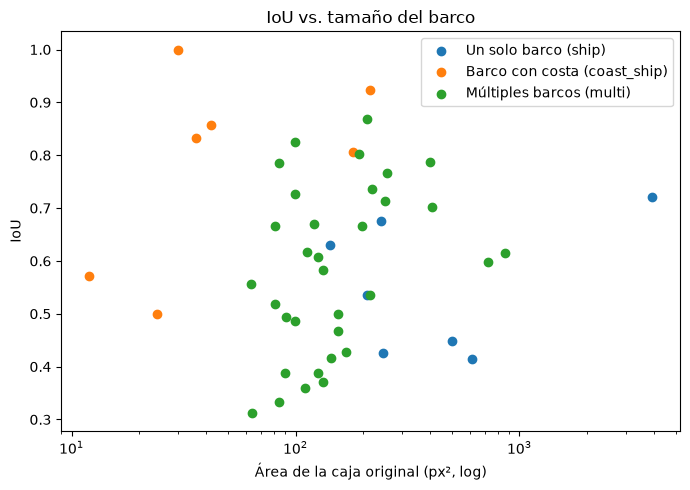

In [9]:
# Relación entre el tamaño de la caja y su IoU, y tamaño relativo de SAM frente a la etiqueta original
print(f"Correlación (Pearson) log(área original) vs IoU: {np.corrcoef(np.log(df['area_orig']), df['iou'])[0, 1]:.3f}")
print(f"SAM más pequeña que la original: {(df['razon_area'] < 1).sum()} de {len(df)} cajas "
      f"(razón de área media = {df['razon_area'].mean():.2f}, mediana = {df['razon_area'].median():.2f})")
print("\nRazón de área SAM/original por categoría:")
print(df.groupby("categoria")["razon_area"].agg(["mean", "median"]).round(3))

fig, ax = plt.subplots(figsize=(7, 5))
for cat, color in (("ship", "tab:blue"), ("coast_ship", "tab:orange"), ("multi", "tab:green")):
    sub = df[df["categoria"] == cat]
    ax.scatter(sub["area_orig"], sub["iou"], c=color, label=f"{CATEGORY_NAMES[cat]} ({cat})")
ax.legend()
ax.set_xscale("log"); ax.set_xlabel("Área de la caja original (px², log)"); ax.set_ylabel("IoU")
ax.set_title("IoU vs. tamaño del barco")
plt.tight_layout()
plt.show()

## Análisis y conclusiones

### Cualitativo (a partir de las imágenes)
- **La caja humana suele dejar más margen de agua que la de SAM.** En los zooms de `s0305`, `s0859`, `m0211` y `m0150` el recuadro verde rodea al barco con un borde visible de agua (en `m0150`, un barco grande, la caja humana se extiende claramente por debajo del casco), mientras que el recuadro rojo queda ceñido al casco. Es coherente con que las etiquetas originales se dibujaron a mano con el mouse, donde resulta más cómodo encerrar el barco con margen que ajustarse al píxel.
- **SAM no siempre es el que acierta mejor.** En `x0191` la caja roja deja fuera el extremo derecho del barco, que la caja verde sí cubre; en `x0566` la de SAM queda ligeramente más ancha que la humana. En esos casos las dos cajas coinciden bien (IoU 0.86 y 0.92), pero la diferencia no es "margen sobrante" sino un pequeño desplazamiento o recorte.
- **Barcos con estela** (`s0859`): ambas cajas se limitan al casco y dejan la estela fuera; SAM la recorta más, y la caja se vuelve estrecha y baja de tamaño (IoU 0.68).
- **Barcos muy pequeños** (`x0209` de 12 px², `x0412` de 24 px², `x0405` de 30 px²): con tan pocos píxeles un error de 1 px cambia mucho el IoU. Es el caso de `x0405`, donde las cajas son idénticas (IoU 1.00), frente a `x0209`, con IoU 0.57 por 1–2 px de diferencia. El IoU es muy sensible aquí y no distingue "error real" de "ruido de píxel".
- **Barcos junto a costa y vegetación** (`x0191`, `x0566`, `m0211`): SAM no confundió la tierra con el barco en estas muestras, porque se le dio la caja como *prompt*; las diferencias vienen del margen y los bordes del casco, no de objetos extraños.
- **Imágenes con varios barcos pequeños** (`m0224`, `m0230`, `m0211`): es donde SAM se aleja más de la etiqueta humana, con varias cajas de SAM que ocupan solo 30–60 % del área humana.

### Cuantitativo (IoU, 21 imágenes / 47 barcos)
- **IoU medio global = 0.61** (mediana 0.61, mín 0.31, máx 1.00, desv. est. 0.17). El **30 %** de las cajas (14 de 47) tiene IoU < 0.5, por lo que el acuerdo es moderado.
- **Por categoría:** barco con costa 0.78 (0 % < 0.5), múltiples barcos 0.59 (33 % < 0.5), un solo barco 0.55 (43 % < 0.5).
- **SAM produce cajas más pequeñas:** en 44 de 47 casos el área de SAM es menor que la original (razón de área media 0.67; 0.86 en `coast_ship`, 0.64 en `multi`, 0.61 en `ship`), y en 31 de 47 la caja SAM queda completamente contenida en la humana. La mayor parte de la discrepancia es margen sobrante en la etiqueta humana, no barcos localizados en otro sitio.
- **El tamaño no explica el IoU:** la correlación entre log(área original) e IoU es prácticamente nula (r ≈ 0.02). Los valores más bajos (`m0230` barco 9 con 0.31, `m0230` barco 1 con 0.37, `m0224` barco 4 con 0.39) son cajas pequeñas donde SAM ocupa menos de la mitad del área humana; los más altos (`x0405` 1.00, `x0566` 0.92, `x0191` 0.86) son barcos donde SAM y humano coinciden en el margen.
- Un IoU de 0.5–0.7 no significa que una etiqueta esté mal: para cajas muy ajustadas, dos anotadores honestos pueden diferir en 1–2 px y obtener valores así. Ese ruido de anotación afecta a cualquier detector evaluado con IoU ≥ 0.5 sobre estas etiquetas.

### Conclusión general
Las etiquetas SAM y las originales **coinciden en la localización de los barcos** (la gran mayoría de las cajas se solapa y SAM casi siempre queda dentro de la humana), pero **difieren en el ajuste**: la anotación humana es más generosa, SAM es más ceñida y, en barcos pequeños o con bordes difusos, puede recortar un extremo del casco. El IoU medio de 0.61 refleja principalmente esa diferencia de margen, no errores de localización. Para entrenar un detector, las etiquetas de SAM pueden ser más ajustadas, pero conviene revisarlas en barcos pequeños o con estela.

**Limitación:** solo hay 21 imágenes con etiquetas SAM (7 por tipo) y 47 cajas, de las cuales 33 son de `multi`. Con 7 cajas en `ship` y `coast_ship`, las comparaciones entre categorías son indicativas y poco estables: con otro conjunto de imágenes el orden entre categorías cambió respecto de una ejecución anterior, lo que confirma que no se deben sacar conclusiones fuertes sobre qué tipo de imagen es más difícil.